In [ ]:
# SVM is mainly used for complex data compresion 
# for classification problem 
# binary classification 
# ex : spam vs not spam , cat vs dog

# Problems with logistic regression 

# logisitic regression works well when data is linearly separable 
# but if data is complex 
# and classes overlap 
# and desiciion boundary is not right 

# then SVM Works well 

# y = mx+c 
# what are parameters ? 
# values which learn from the given data 
# what are the hyper parameters ? 
# values which are given by us , and doent depend on the data 

# for every hyperparameters need to be changed 

SVM Image
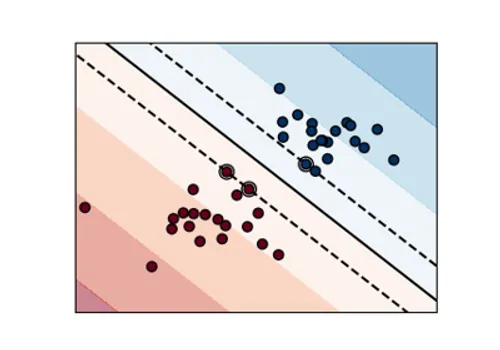

In [ ]:
Mathematical

eq of hyperplane :
w.x + b = 0 
w = weights
x =input 
b= bias / intercept 
prediction rule : 
if w.x + b >= 0 --> class 1 
else w.x + b <0 --> class 0

In [10]:
w = 2 
x = 3 
b = -4

y = w*x + b 
print(y)

if y>0:
    print("class1")
else:
    print("class2")

2
class1


In [1]:
import pandas as pd 
import numpy as np 

In [2]:
df = pd.read_csv("gender_classification_v7.csv")
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  5001 non-null   int64  
 1   forehead_width_cm          5001 non-null   float64
 2   forehead_height_cm         5001 non-null   float64
 3   nose_wide                  5001 non-null   int64  
 4   nose_long                  5001 non-null   int64  
 5   lips_thin                  5001 non-null   int64  
 6   distance_nose_to_lip_long  5001 non-null   int64  
 7   gender                     5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB


In [4]:
df.describe()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long
count,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000
mean,0.869626,13.181484,5.946311,0.493901,0.507898,0.493101,0.498900
std,0.336748,1.107128,0.541268,0.500013,0.499988,0.500002,0.500049
min,0.000000,11.400000,5.100000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,12.200000,5.500000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,13.100000,5.900000,0.000000,1.000000,0.000000,0.000000
75%,1.000000,14.000000,6.400000,1.000000,1.000000,1.000000,1.000000
max,1.000000,15.500000,7.100000,1.000000,1.000000,1.000000,1.000000


In [5]:
df.gender.unique()

array(['Male', 'Female'], dtype=object)

In [7]:
df.gender.replace({"Male":1 , "Female":0} , inplace = True)

C:\Users\SriHarshaK\AppData\Local\Temp\ipykernel_23036\894871826.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.gender.replace({"Male":1 , "Female":0} , inplace = True)


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report,confusion_matrix

In [48]:
def model(df):
    X = df.iloc[: , :-1]
    y = df.iloc[: , -1]
    X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2)
    sc = StandardScaler()
    X_train_scaled = sc.fit_transform(X_train)
    X_test_scaled = sc.transform (X_test)
    lg = SVC(kernel='linear' , C = 1.0 ,gamma = 'auto', verbose=True ,break_ties=True)
    lg.fit(X_train , y_train)
    lg_preds = lg.predict(X_test)
    print(classification_report(y_test , lg_preds))
    cm = confusion_matrix(y_test , lg_preds)
    print(cm)

In [49]:
model(df)

[LibSVM]              precision    recall  f1-score   support

           0       0.97      0.97      0.97       495
           1       0.97      0.97      0.97       506

    accuracy                           0.97      1001
   macro avg       0.97      0.97      0.97      1001
weighted avg       0.97      0.97      0.97      1001

[[480  15]
 [ 15 491]]


linear = linear data 

poly = polynimial relation ship 

rbf = Non-liner complex data 

sigmoid = Neural network like behavior

if the following case happens then the result will be 

small c -> wider margin -> underfitting 
large c -> tires to classify all points -> overfitting 

